# 1) PSIC Model Training
- The goal here is to train and test various models to utilize for MTG using the PSIC data
- We will use the features created from the referenced study
- Then, we will attempt to recreate the RFR model used for the study
- Out of the top performing models, we will see how they will perform for the other higher-level targets, `arousal` and `valence`
- Next, we will perform post-EDA on the weighted variables for each model and the PCC values.
- Lastly, we will save the top performing model for our MTG data labeling. 

## Library Imports

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

## Uploading Data

### PSIC Features

In [2]:
# Features obtained from PSIC study (Through pipeline)
psic_features = pd.read_excel('combine_450inputs.xlsx')

In [3]:
psic_features.head(3)

,depth,spectral bandwidth 1,spectral bandwidth 2,spectral bandwidth 3,spectral bandwidth 4,spectral bandwidth 5,spectral bandwidth 6,spectral bandwidth 7,spectral bandwidth 8,spectral bandwidth 9,...,tonnetz 42,tonnetz 43,tonnetz 44,tonnetz 45,tonnetz 46,tonnetz 47,tonnetz 48,tonnetz 49,tonnetz 50,tempo
0,0.458333,-298.876299,676.946012,-153.485176,266.743403,-253.104485,13.143708,52.227637,141.805801,26.241194,...,0.251080,0.076972,-0.408833,-0.114411,0.103221,0.119133,-0.072968,-0.514818,-0.065896,120.185320
1,0.791667,584.988589,386.434128,275.010790,177.633447,-72.733658,-147.639121,40.327523,160.830124,-66.889020,...,-0.650331,-0.071566,0.403185,1.304614,-0.650505,0.876201,0.625752,0.051228,0.477440,143.554688
2,0.375000,-149.860037,202.581415,101.563171,-42.865109,31.440305,54.837523,-61.631702,-113.337131,-4.957636,...,-0.342655,0.042923,-0.198381,-0.073593,0.252805,0.125377,-0.198292,0.407522,0.368277,120.185320


In [4]:
psic_features['depth'].max()

1.0

In [5]:
psic_features['depth'].min()

0.0

The depth is showing to be 0-1, though the paper and PSIC high features study used a Likert scale -2 - 2.  
Downloading the high features dataset to show scaling.

In [6]:
# scaled depth in [0,1]
depth_scaled = psic_features["depth"]

# back to [-2,2]
depth_raw = depth_scaled * 4 - 2

print("Reverted Depth targets")
depth_raw.head(3)

Reverted Depth targets


0   -0.166667
1    1.166667
2   -0.500000
Name: depth, dtype: float64

### Target Data

In [7]:
high_features = pd.read_excel('general_data.xlsx')
high_features = high_features.set_index('id')

In [8]:
print("Original Depth Data")
high_features.head(3)

Original Depth Data


,arousal_m,valence_m,depth_m,arousal_sd,valence_sd,depth_sd
id,,,,,,
1,1.333333,0.666667,-0.166667,0.516398,1.366260,1.329160
2,-0.666667,0.166667,1.166667,1.032796,1.471960,0.752773
3,0.833333,1.500000,-0.500000,1.169045,0.547723,1.760682


Here, we can now see that the target `depth` matches `depth_m` in the original dataset

In [9]:
# original valence in [-2, 2]
valence_raw = high_features["valence_m"]

# scaled to [0,1]
valence_scaled = (valence_raw + 2) / 4

print("Scaled Valence targets")
valence_scaled.head(3)

Scaled Valence targets


id
1    0.666667
2    0.541667
3    0.875000
Name: valence_m, dtype: float64

In [10]:
# original valence in [-2, 2]
arousal_raw = high_features["arousal_m"]

# scaled to [0,1]
arousal_scaled = (arousal_raw + 2) / 4

print("Scaled Valence targets")
arousal_scaled.head(3)

Scaled Valence targets


id
1    0.833333
2    0.333333
3    0.708333
Name: arousal_m, dtype: float64

In [11]:
scaled_features = pd.DataFrame({
    "arousal": np.ravel(arousal_scaled),
    "valence": np.ravel(valence_scaled),
    "depth":   np.ravel(depth_scaled),
})

scaled_features.head()

,arousal,valence,depth
0,0.833333,0.666667,0.458333
1,0.333333,0.541667,0.791667
2,0.708333,0.875000,0.375000
3,0.416667,0.166667,0.750000
4,0.750000,0.750000,0.500000


In [12]:
scaled_features.corr()

,arousal,valence,depth
arousal,1.000000,0.555943,-0.050050
valence,0.555943,1.000000,-0.046022
depth,-0.050050,-0.046022,1.000000


In [13]:
psic_features.shape

(3839, 402)

In [14]:
psic_features.isna().sum()

depth                   0
spectral bandwidth 1    0
spectral bandwidth 2    0
spectral bandwidth 3    0
spectral bandwidth 4    0
                       ..
tonnetz 47              0
tonnetz 48              0
tonnetz 49              0
tonnetz 50              0
tempo                   0
Length: 402, dtype: int64

## Splitting Data

In [15]:
# X=Features, y=Target
X = psic_features.drop('depth', axis=1)
y = psic_features['depth']
y2 = scaled_features['arousal']
y3 = scaled_features['valence']

#Splitting the data of the features and target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
X_train, X_test, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=12345)
X_train, X_test, y3_train, y3_test = train_test_split(X, y3, test_size=0.2, random_state=12345)

In [16]:
#Checking the shape of each dataset
print("Shape of training sets")
print(X_train.shape)
print(y_train.shape)

print("Shape of testing sets")
print(X_test.shape)
print(y_test.shape)


Shape of training sets
(3071, 401)
(3071,)
Shape of testing sets
(768, 401)
(768,)


## ML

In [17]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

### Baselines

#### `depth`

In [18]:
y_pred_baseline = np.full_like(y_test, fill_value=np.mean(y_train), dtype=float)

base_r2 = r2_score(y_test, y_pred_baseline)
base_mae = mean_absolute_error(y_test, y_pred_baseline)
mse = mean_squared_error(y_test, y_pred_baseline)
base_rmse = np.sqrt(mse)

print("Depth baseline")
print(f"R2: {base_r2:.2}, RMSE: {base_rmse:.2}, MAE: {base_mae:.2}")

Depth baseline
R2: -0.00034, RMSE: 0.24, MAE: 0.21


#### `arousal`

In [19]:
y2_pred_baseline = np.full_like(y2_test, fill_value=np.mean(y2_train), dtype=float)

base_r2_a = r2_score(y2_test, y_pred_baseline)
base_mae_a = mean_absolute_error(y2_test, y2_pred_baseline)
mse = mean_squared_error(y2_test, y2_pred_baseline)
base_rmse_a = np.sqrt(mse)

print("Arousal baseline")
print(f"R2: {base_r2_a:.2}, RMSE: {base_mae_a:.2}, MAE: {base_rmse_a:.2}")

Arousal baseline
R2: -5.4e-05, RMSE: 0.21, MAE: 0.25


#### `valence`

In [20]:
y3_pred_baseline = np.full_like(y3_test, fill_value=np.mean(y3_train), dtype=float)

base_r2_v = r2_score(y3_test, y3_pred_baseline)
base_mae_v = mean_absolute_error(y3_test, y3_pred_baseline)
mse = mean_squared_error(y3_test, y3_pred_baseline)
base_rmse_v = np.sqrt(mse)

print("Valence baseline")
print(f"R2: {base_r2_v:.2}, RMSE: {base_mae_v:.2}, MAE: {base_rmse_v:.2}")

Valence baseline
R2: -2.5e-06, RMSE: 0.24, MAE: 0.27


### Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
# creating model
lr_model = LinearRegression()

# training
lr_model.fit(X_train, y_train)

LinearRegression()

In [23]:
# prediction
predictions = lr_model.predict(X_test)

In [24]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
pcc, _ = pearsonr(y_test, predictions)

# improvements
improve_R2 = r_2 - base_r2
improve_RMSE = 1 - (rmse/base_rmse)
improve_MAE = 1 - (mae/base_mae)

In [25]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae,],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline Model Δ (Model - Baseline) % Improvement
    R²   -0.000 0.481               +0.481          +48%
  RMSE    0.244 0.176               -0.068          +28%
   MAE    0.206 0.140               -0.066          +32%

Model PCC: 0.699


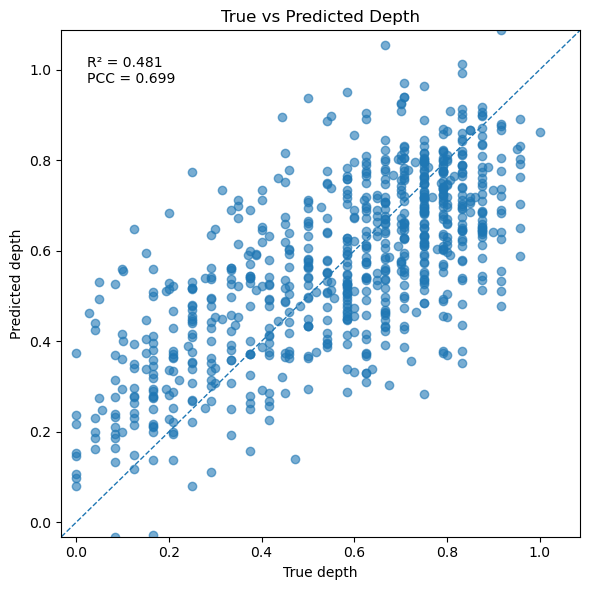

In [26]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True depth")
plt.ylabel("Predicted depth")
plt.title("True vs Predicted Depth")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

### Random Forrest Regressor

In [27]:
from sklearn.ensemble import RandomForestRegressor

#### `depth`

In [28]:
# creating model
rfr = RandomForestRegressor(random_state=12345)

# training
rfr.fit(X_train, y_train)

RandomForestRegressor(random_state=12345)

In [29]:
# prediction
predictions = rfr.predict(X_test)

In [30]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
pcc, _ = pearsonr(y_test, predictions)

# improvements
improve_R2 = r_2 - base_r2
improve_RMSE = 1 - (rmse/base_rmse)
improve_MAE = 1 - (mae/base_mae)

In [31]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline Model Δ (Model - Baseline) % Improvement
    R²   -0.000 0.534               +0.534          +53%
  RMSE    0.244 0.167               -0.077          +32%
   MAE    0.206 0.131               -0.075          +36%

Model PCC: 0.731


The authors reported a PCC value of 0.722 and an RMSE of .173.  
We have successfully replicated the RFR model using the same features.  
With that, we will examine if there are in fact more suitable models to try.

In [3]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True depth")
plt.ylabel("Predicted depth")
plt.title("True vs Predicted Depth")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

# saving as JPEG
plt.savefig("true_pred__valence_RFR.jpg",
            dpi=300,
            bbox_inches="tight")

plt.tight_layout()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 600x600 with 0 Axes>

#### `arousal`

- Examining if the model can also perform for `arousal`

In [33]:
# creating model
rfr_2 = RandomForestRegressor(random_state=12345)

# training
rfr_2.fit(X_train, y2_train)

RandomForestRegressor(random_state=12345)

In [34]:
# prediction
predictions2 = rfr_2.predict(X_test)

In [35]:
# metrics
r_2 = r2_score(y2_test, predictions2)
mse = mean_squared_error(y2_test, predictions2)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y2_test, predictions2)
pcc, _ = pearsonr(y2_test, predictions2)

# improvements
improve_R2 = r_2 - base_r2_a
improve_RMSE = 1 - (rmse/base_rmse_a)
improve_MAE = 1 - (mae/base_mae_a)

In [36]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline  Model Δ (Model - Baseline) % Improvement
    R²   -0.000 -0.022               -0.022           -2%
  RMSE    0.244  0.249               +0.005           -1%
   MAE    0.206  0.212               +0.005           -1%

Model PCC: 0.058


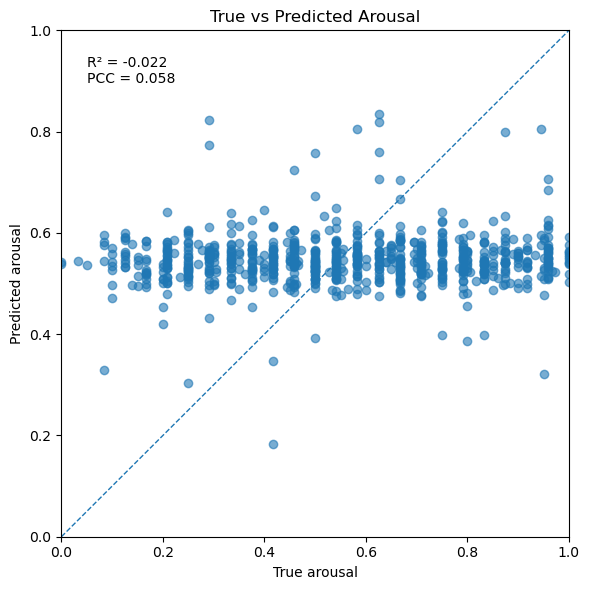

In [37]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y2_test, predictions2, alpha=0.6)

# 45° reference line
lims = [
    min(y2_test.min(), predictions2.min()),
    max(y2_test.max(), predictions2.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True arousal")
plt.ylabel("Predicted arousal")
plt.title("True vs Predicted Arousal")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

Above, we can see that the model was not able to predict any meaningful way of the target `arousal`

#### `valence`

- Examining if the model can also perform for `valence`

In [38]:
# creating model
rfr_3 = RandomForestRegressor(random_state=12345)

# training
rfr_3.fit(X_train, y3_train)

RandomForestRegressor(random_state=12345)

In [39]:
# prediction
predictions3 = rfr_3.predict(X_test)

In [40]:
# metrics
r_2 = r2_score(y3_test, predictions3)
mse = mean_squared_error(y3_test, predictions3)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y3_test, predictions3)
pcc, _ = pearsonr(y3_test, predictions3)

# improvements
improve_R2 = r_2 - base_r2_v
improve_RMSE = 1 - (rmse/base_rmse_v)
improve_MAE = 1 - (mae/base_mae_v)

In [41]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline  Model Δ (Model - Baseline) % Improvement
    R²   -0.000 -0.027               -0.027           -3%
  RMSE    0.244  0.270               +0.026           -1%
   MAE    0.206  0.238               +0.032           -1%

Model PCC: 0.016


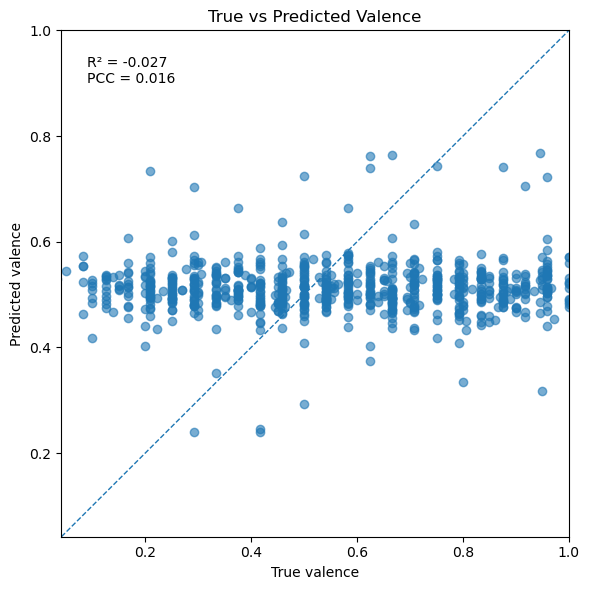

In [42]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y2_test, predictions3, alpha=0.6)

# 45° reference line
lims = [
    min(y3_test.min(), predictions3.min()),
    max(y3_test.max(), predictions3.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True valence")
plt.ylabel("Predicted valence")
plt.title("True vs Predicted Valence")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

Appears that the model is not effective for `valence`

### AdaBoost Regressor

In [43]:
from sklearn.ensemble import AdaBoostRegressor

In [44]:
# creating model
ada_model = AdaBoostRegressor(random_state=12345)

# training
ada_model.fit(X_train, y_train)

AdaBoostRegressor(random_state=12345)

In [45]:
# prediction
predictions = ada_model.predict(X_test)

In [46]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
pcc, _ = pearsonr(y_test, predictions)

# improvements
improve_R2 = r_2 - base_r2
improve_RMSE = 1 - (rmse/base_rmse)
improve_MAE = 1 - (mae/base_mae)

In [47]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline Model Δ (Model - Baseline) % Improvement
    R²   -0.000 0.482               +0.482          +48%
  RMSE    0.244 0.176               -0.068          +28%
   MAE    0.206 0.146               -0.061          +29%

Model PCC: 0.725


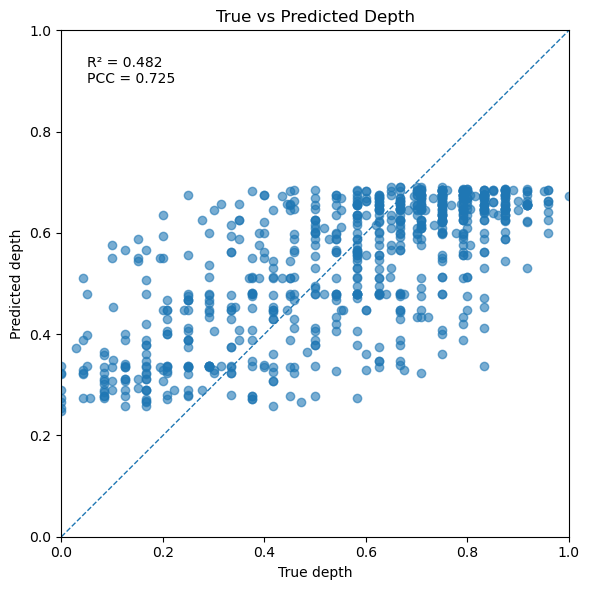

In [48]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True depth")
plt.ylabel("Predicted depth")
plt.title("True vs Predicted Depth")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

### Bagging Regressor

In [49]:
from sklearn.ensemble import BaggingRegressor

In [50]:
# creating model
bag_model = BaggingRegressor(random_state=12345)

# training
bag_model.fit(X_train, y_train)

# prediction
predictions = bag_model.predict(X_test)

In [51]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
pcc, _ = pearsonr(y_test, predictions)

# improvements
improve_R2 = r_2 - base_r2
improve_RMSE = 1 - (rmse/base_rmse)
improve_MAE = 1 - (mae/base_mae)

In [52]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline Model Δ (Model - Baseline) % Improvement
    R²   -0.000 0.508               +0.508          +51%
  RMSE    0.244 0.171               -0.073          +30%
   MAE    0.206 0.136               -0.070          +34%

Model PCC: 0.713


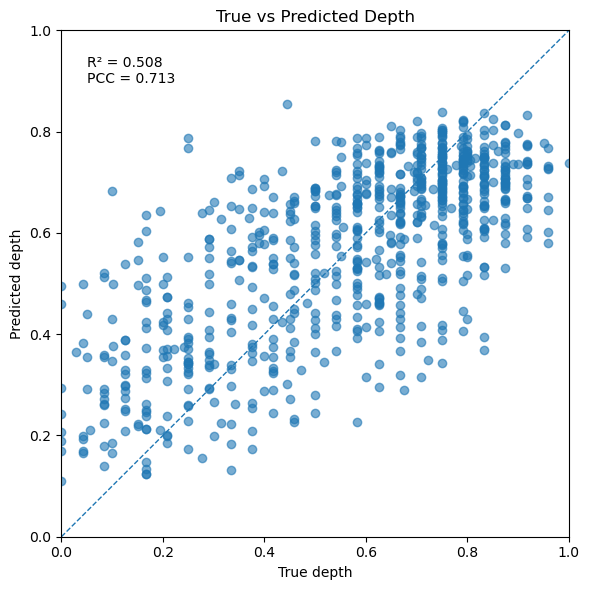

In [53]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True depth")
plt.ylabel("Predicted depth")
plt.title("True vs Predicted Depth")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

### Gradient Boosting Regressor

In [54]:
from sklearn.ensemble import GradientBoostingRegressor

In [55]:
# creating model
gbr = GradientBoostingRegressor(random_state=12345)

# training
gbr.fit(X_train, y_train)

# prediction
predictions = gbr.predict(X_test)

In [56]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
pcc, _ = pearsonr(y_test, predictions)

# improvements
improve_R2 = r_2 - base_r2
improve_RMSE = 1 - (rmse/base_rmse)
improve_MAE = 1 - (mae/base_mae)

In [57]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline Model Δ (Model - Baseline) % Improvement
    R²   -0.000 0.534               +0.534          +53%
  RMSE    0.244 0.167               -0.077          +32%
   MAE    0.206 0.131               -0.075          +36%

Model PCC: 0.731


Here, we can see that the GBR may perform better than the RFR.

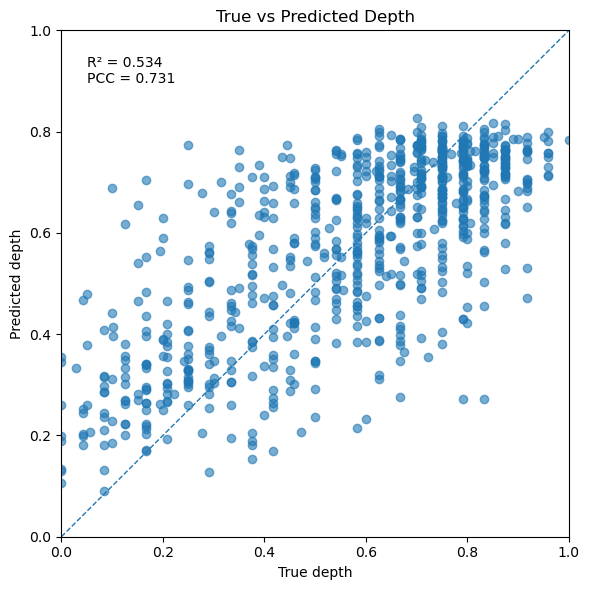

In [58]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True depth")
plt.ylabel("Predicted depth")
plt.title("True vs Predicted Depth")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

plt.tight_layout()
plt.show()

### XGBoost

#### `depth`

In [80]:
# Had to rerun for the final graph in summary
import xgboost as xgb

# Define XGBRegressor model parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Instantiate XGBRegressor with the parameters
xgb = xgb.XGBRegressor(**params)

# Train the model
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [60]:
# prediction
predictions = xgb.predict(X_test)

In [61]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
pcc, _ = pearsonr(y_test, predictions)

# improvements
improve_R2 = r_2 - base_r2
improve_RMSE = 1 - (rmse/base_rmse)
improve_MAE = 1 - (mae/base_mae)

In [62]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline Model Δ (Model - Baseline) % Improvement
    R²   -0.000 0.536               +0.536          +54%
  RMSE    0.244 0.166               -0.078          +32%
   MAE    0.206 0.130               -0.076          +37%

Model PCC: 0.732


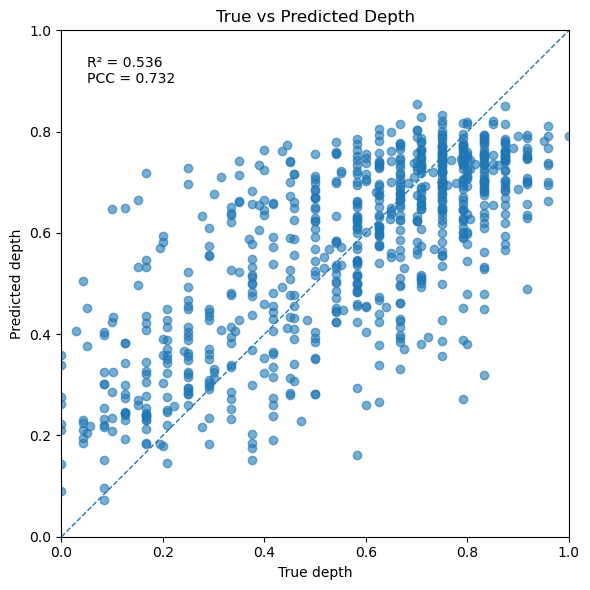

In [63]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True depth")
plt.ylabel("Predicted depth")
plt.title("True vs Predicted Depth")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

# saving as JPEG
plt.savefig("true_pred_depth_XGB.jpg",
            dpi=300,
            bbox_inches="tight")

plt.tight_layout()
plt.show()

#### `arousal`

In [64]:
import xgboost as xgb

# Define XGBRegressor model parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Instantiate XGBRegressor with the parameters
xgb_model = xgb.XGBRegressor(**params)

# Train the model
xgb_model.fit(X_train, y2_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
# prediction
predictions = xgb_model.predict(X_test)

In [66]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y2_test, predictions)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y2_test, predictions)
pcc, _ = pearsonr(y2_test, predictions)

# improvements
improve_R2 = r_2 - base_r2_a
improve_RMSE = 1 - (rmse/base_rmse_a)
improve_MAE = 1 - (mae/base_mae_a)

In [67]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline  Model Δ (Model - Baseline) % Improvement
    R²   -0.000 -0.119               -0.119          -12%
  RMSE    0.244  0.252               +0.008           -2%
   MAE    0.206  0.214               +0.008           -2%

Model PCC: 0.019


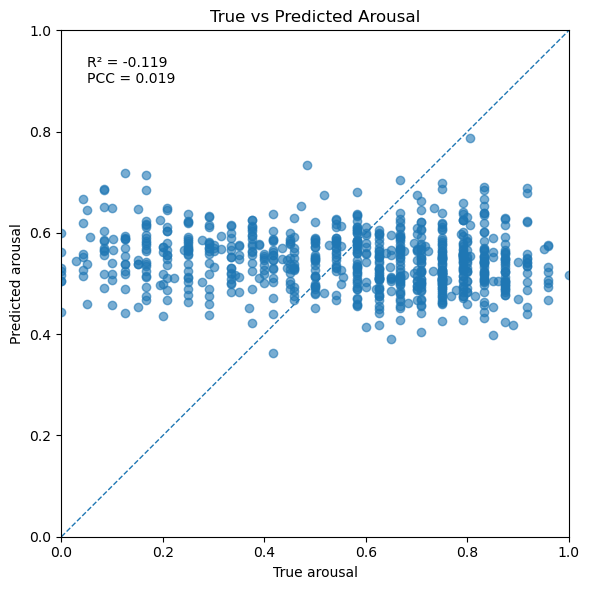

In [68]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True arousal")
plt.ylabel("Predicted arousal")
plt.title("True vs Predicted Arousal")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

# saving as JPEG
plt.savefig("true_pred__arousal_XGB.jpg",
            dpi=300,
            bbox_inches="tight")

plt.tight_layout()
plt.show()

#### `valence`

In [69]:
import xgboost as xgb

# Define XGBRegressor model parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 3,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

# Instantiate XGBRegressor with the parameters
xgb_model = xgb.XGBRegressor(**params)

# Train the model
xgb_model.fit(X_train, y3_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [70]:
# prediction
predictions = xgb_model.predict(X_test)

In [71]:
# metrics
r_2 = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, predictions)
pcc, _ = pearsonr(y_test, predictions)

# improvements
improve_R2 = r_2 - base_r2_v
improve_RMSE = 1 - (rmse/base_rmse_v)
improve_MAE = 1 - (mae/base_mae_v)

In [72]:
# Metrics
df = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Baseline": [base_r2, base_rmse, base_mae],
    "Model": [r_2, rmse, mae],
    "Δ (Model - Baseline)": [r_2 - base_r2, rmse - base_rmse, mae - base_mae],
    "% Improvement": [improve_R2, improve_RMSE, improve_MAE],
})

# formatting
df["Baseline"] = df["Baseline"].map(lambda x: f"{x:.3f}")
df["Model"] = df["Model"].map(lambda x: f"{x:.3f}")
df["Δ (Model - Baseline)"] = df["Δ (Model - Baseline)"].map(lambda x: f"{x:+.3f}")
df["% Improvement"] = df["% Improvement"].map(lambda x: "—" if pd.isna(x) else f"{x:+.0%}")

# Results
print("-----Model Performance-----")
print()
print(df.to_string(index=False))
print()
print(f"Model PCC: {pcc:.3f}")

-----Model Performance-----

Metric Baseline  Model Δ (Model - Baseline) % Improvement
    R²   -0.000 -0.162               -0.162          -16%
  RMSE    0.244  0.263               +0.019           +1%
   MAE    0.206  0.229               +0.022           +3%

Model PCC: -0.112


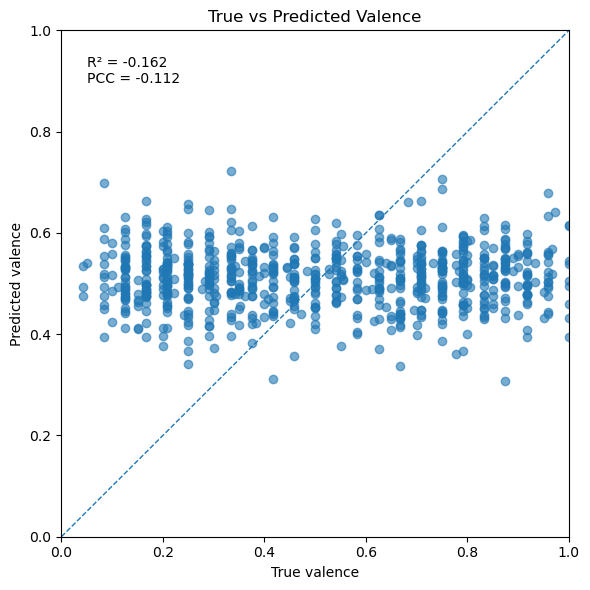

In [73]:
# Plotting R_2 and PCC scores

plt.figure(figsize=(6, 6))
plt.scatter(y3_test, predictions, alpha=0.6)

# 45° reference line
lims = [
    min(y_test.min(), predictions.min()),
    max(y_test.max(), predictions.max())
]
plt.plot(lims, lims, "--", linewidth=1)
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("True valence")
plt.ylabel("Predicted valence")
plt.title("True vs Predicted Valence")

# Annotate metrics
plt.text(
    0.05, 0.95,
    f"R² = {r_2:.3f}\nPCC = {pcc:.3f}",
    transform=plt.gca().transAxes,
    va="top"
)

# saving as JPEG
plt.savefig("true_pred__valence_XGB.jpg",
            dpi=300,
            bbox_inches="tight")

plt.tight_layout()
plt.show()

### Fine-Tuning
- Essentially skipped as they did not improve performance and XGBoost was already improved compared to RFR and GBR.

In [74]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import make_scorer
import time

In [75]:
# Cross-Validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Scorer
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

***Random Forest Regressor***

In [76]:
# # Setting time
# start_time = time.time()

# # Random Forest Regressor
# rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# # Parameters
# rf_space = {
#     "n_estimators": [100, 200, 400],
#     "max_depth": [10, 20, 30],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", 0.5],
#     "bootstrap": [True],
# }

# # Randomized Search
# rf_search = RandomizedSearchCV(
#     rf,
#     param_distributions=rf_space,
#     n_iter=20,
#     scoring=rmse_scorer,   # or "r2"
#     cv=cv,
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

# # Best fit model
# rf_search.fit(X_train, y_train)
# best_rf = rf_search.best_estimator_

# # Calculate elapsed time
# elapsed_time = time.time() - start_time
# hours, remainder = divmod(elapsed_time, 3600)
# minutes, seconds = divmod(remainder, 60)

# print("RF best params:", rf_search.best_params_)
# print(f"RF CV RMSE: {-rf_search.best_score_:.3f}")
# print(f"Time elapsed: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

**Fine-Tuning did not improve the Random Forest Regressor**

***Gradient Boosting Regressor***

In [77]:
# # Setting time
# start_time = time.time()

# # Gradient Boosting Regressor
# gbr = GradientBoostingRegressor(random_state=42)

# # Parameters
# gbr_space = {
#     "n_estimators": [100, 300, 500],
#     "learning_rate": [0.05, 0.1, 0.2],
#     "max_depth": [2, 3, 4],
#     "subsample": [0.7, 0.9],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2],
#     "max_features": ["sqrt", 0.7],
# }

# # Randomized Search
# gbr_search = RandomizedSearchCV(
#     gbr,
#     param_distributions=gbr_space,
#     n_iter=20,
#     scoring=rmse_scorer,
#     cv=cv,
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

# # Best fit model
# gbr_search.fit(X_train, y_train)
# best_gbr = gbr_search.best_estimator_

# # Calculate elapsed time
# elapsed_time = time.time() - start_time
# hours, remainder = divmod(elapsed_time, 3600)
# minutes, seconds = divmod(remainder, 60)

# print("GBR best params:", gbr_search.best_params_)
# print(f"GBR CV RMSE: {-gbr_search.best_score_:.3f}")
# print(f"Time elapsed: {int(hours)}h {int(minutes)}m {seconds:.2f}s")

**Fine-Tuning did not improve the Gradient Boosting Regressor**

Since neither models increased performance with fine-tuning but had higher times to run, we will save the simpler versions.  
However, higher performance may be reached with stronger tuning parameters.

## Summary Metrics/Best Model

- While able to successfully replicate the RFR model from Xu et al, the XGBoost performed the best and with the shortest time.  
With that, we will go with the XGBoost for Pseudolabelling.

- While we were able to successfully create a model targeting depth, we could not create one for arousal or valence.
Therefore, we will move forward with labelling depth predictions on the MTG dataset

In [78]:
def feature_to_group(col):
    if col.startswith("spectral contrast"):
        return "Spectral contrast (PCA)"
    if col.startswith("spectral flatness"):
        return "Spectral flatness (PCA)"
    if col.startswith("tonnetz"):
        return "Tonnetz (PCA)"
    if col.startswith("MFCCs"):
        return "MFCCs (PCA)"
    if col.startswith("chromagram"):
        return "Chromagram (PCA)"
    if col.startswith("spectral centroid"):
        return "Spectral centroid (PCA)"
    if col.startswith("spectral bandwidth"):
        return "Spectral bandwidth (PCA)"
    if col.startswith("spectral rolloff"):
        return "Spectral rolloff (PCA)"
    if col == "tempo":
        return "Tempo"
    return "Other"

                          Random Forest  Gradient Boost    XGBoost
group                                                             
Spectral contrast (PCA)       50.020985       58.898742  20.834139
MFCCs (PCA)                    9.871918       10.728495  12.145373
Spectral bandwidth (PCA)       8.495532        7.280379   9.368081
Spectral flatness (PCA)        6.858020        7.815646  15.936759
Tonnetz (PCA)                  6.736145        4.481946  13.496320
Chromagram (PCA)               6.675484        5.861894  10.146167
Spectral centroid (PCA)        5.596946        2.314837   9.456242
Spectral rolloff (PCA)         5.272308        2.081014   8.066448
Tempo                          0.472662        0.537046   0.550476


<Figure size 800x600 with 0 Axes>

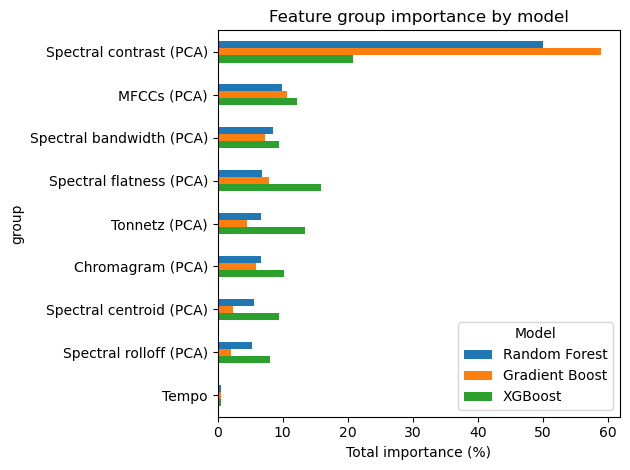

In [81]:
# models dict
models = {
    "Random Forest": rfr,
    "Gradient Boost": gbr,
    "XGBoost": xgb,
}

group_tables = []

for model_name, model in models.items():
    # 1) base feature importances (same for all three)
    feat_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_,
    })

    # 2) map each feature to a group
    feat_df["group"] = feat_df["feature"].apply(feature_to_group)

    # 3) sum importances by group
    group_imp = (
        feat_df
        .groupby("group")["importance"]
        .sum()
        .sort_values(ascending=False)
    )

    # 4) convert to % of total for that model
    group_imp_pct = 100 * group_imp / group_imp.sum()

    # rename Series to model name so we can concat later
    group_tables.append(group_imp_pct.rename(model_name))

# combine: rows = groups, columns = models
group_imp_all = pd.concat(group_tables, axis=1).fillna(0)

print(group_imp_all)  # optional

# plot
plt.figure(figsize=(8, 6))
group_imp_all.plot(kind="barh")
plt.xlabel("Total importance (%)")
plt.title("Feature group importance by model")
plt.gca().invert_yaxis()
plt.legend(title="Model")
plt.tight_layout()

# saving as JPEG
plt.savefig("feature_group_importance_models.jpg",
            dpi=300,
            bbox_inches="tight")

plt.show()

- Random Forest and Gradient Boost are heavily influenced by Spectral Contrast.
- XGBoost shows a more even distribution of weight between the PCA features
- Tempo is of low importance across all models - timbre and harmony play a heavier part.

In [82]:
import joblib

joblib.dump(xgb, "depth_model.joblib")

['depth_model.joblib']